# Step 5.2 - Clustering: DBSCAN

**Goal:** Apply DBSCAN as a density-based alternative to K-Means and compare results.

**Why DBSCAN after K-Means?**  
K-Means assumes spherical, roughly equal-sized clusters and requires k as input. DBSCAN makes neither assumption: it discovers clusters of arbitrary shape and size, and labels low-density regions as noise (label -1). Given the low K-Means silhouette scores (0.18 for TF-IDF, 0.11 for Word2Vec), DBSCAN lets us test whether the weak cluster structure is due to K-Means assumptions rather than the data itself.

**Key parameters:**
- `eps` (epsilon): neighbourhood radius. Points within eps of each other are density-connected.
- `min_samples`: minimum points in an eps-neighbourhood to form a core point.

**Tuning strategy:** k-distance plot (also called elbow plot for DBSCAN). For each point, compute the distance to its k-th nearest neighbour. Sorting these distances and plotting them reveals a knee: below the knee = dense core regions, above = noise. The knee value is the recommended eps.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import os

PCA_TFIDF_PATH     = "../data/processed/pca_tfidf_50.npy"
PCA_W2V_PATH       = "../data/processed/pca_w2v_50.npy"
OUTLIER_FLAGS_PATH = "../data/processed/outlier_flags.csv"
CLEAN_DATA_PATH    = "../data/processed/sgbs_clean.csv"
KMEANS_RESULTS     = "../data/processed/kmeans_results.csv"

LABELS_DBSCAN_TFIDF_PATH = "../data/processed/dbscan_labels_tfidf.npy"
LABELS_DBSCAN_W2V_PATH   = "../data/processed/dbscan_labels_w2v.npy"

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../report/figures", exist_ok=True)

X_tfidf = np.load(PCA_TFIDF_PATH)
X_w2v   = np.load(PCA_W2V_PATH)

df_full = pd.read_csv(CLEAN_DATA_PATH)
flags   = pd.read_csv(OUTLIER_FLAGS_PATH)
EXCLUDE = flags.index[flags['exclude'] == True].tolist()
df = df_full.drop(index=EXCLUDE).reset_index(drop=True)

HAUPTGRUPPEN = {
    '1': 'Staatsrecht/Org.',
    '2': 'Zivilrecht/Strafrecht',
    '3': 'Gesundheit',
    '4': 'Erziehung/Wiss.',
    '5': 'Polizei/Militaer',
    '6': 'Finanzen/Lieg.',
    '7': 'Bau/Energie/Umwelt',
    '8': 'Arbeit/Soziales',
    '9': 'Wirtschaft/Verkehr',
}
df['hauptgruppe'] = df['systematic_number'].astype(str).str[0].apply(
    lambda x: x if x in HAUPTGRUPPEN else 'S'
)

km_results = pd.read_csv(KMEANS_RESULTS)

print(f"TF-IDF PCA:   {X_tfidf.shape}")
print(f"Word2Vec PCA: {X_w2v.shape}")
print(f"Docs:         {len(df)}")

TF-IDF PCA:   (730, 50)
Word2Vec PCA: (730, 50)
Docs:         730


## 2. Tune eps - k-Distance Plot

We use `min_samples=5` as a starting point (standard heuristic: 2 * n_dimensions is too large here; 5 is a common default for medium-sized datasets). The k-distance plot is computed for k = min_samples - 1 = 4.

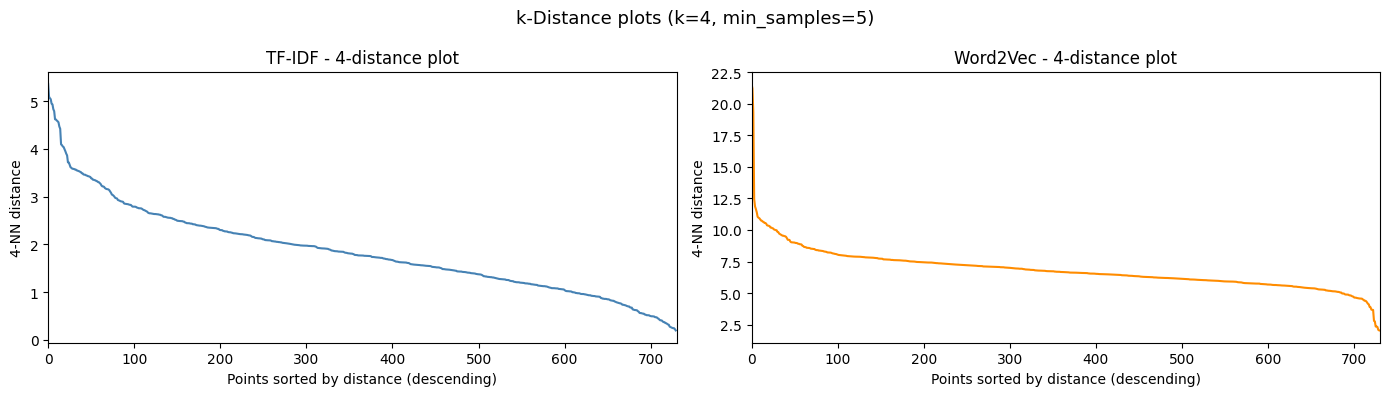

TF-IDF  - distance range: 0.199 .. 5.361
Word2Vec - distance range: 2.053 .. 21.558

Inspect the plots above. The knee in the curve suggests a good eps value.
Percentile reference:
  TF-IDF  p10: 3.0842  Word2Vec p10: 8.4901
  TF-IDF  p25: 2.3708  Word2Vec p25: 7.5339
  TF-IDF  p50: 1.7673  Word2Vec p50: 6.6635
  TF-IDF  p75: 1.2065  Word2Vec p75: 5.9418
  TF-IDF  p90: 0.8191  Word2Vec p90: 5.3471


In [2]:
MIN_SAMPLES = 5
K_DIST = MIN_SAMPLES - 1  # k-th nearest neighbour distance

def kdistance_plot(X, k, ax, title, color):
    nn = NearestNeighbors(n_neighbors=k + 1)  # +1 because point itself is included
    nn.fit(X)
    distances, _ = nn.kneighbors(X)
    kth_distances = np.sort(distances[:, k])[::-1]  # k-th neighbour, sorted descending
    ax.plot(kth_distances, color=color)
    ax.set_title(f"{title} - {k}-distance plot")
    ax.set_xlabel("Points sorted by distance (descending)")
    ax.set_ylabel(f"{k}-NN distance")
    ax.set_xlim(0, len(kth_distances))
    return kth_distances

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
kd_tfidf = kdistance_plot(X_tfidf, K_DIST, axes[0], "TF-IDF",   "steelblue")
kd_w2v   = kdistance_plot(X_w2v,   K_DIST, axes[1], "Word2Vec",  "darkorange")

plt.suptitle(f"k-Distance plots (k={K_DIST}, min_samples={MIN_SAMPLES})", fontsize=13)
plt.tight_layout()
plt.savefig("../report/figures/05_2_dbscan_kdist.png", dpi=150)
plt.show()

print(f"TF-IDF  - distance range: {kd_tfidf[-1]:.3f} .. {kd_tfidf[0]:.3f}")
print(f"Word2Vec - distance range: {kd_w2v[-1]:.3f} .. {kd_w2v[0]:.3f}")
print()
print("Inspect the plots above. The knee in the curve suggests a good eps value.")
print("Percentile reference:")
for p in [10, 25, 50, 75, 90]:
    print(f"  TF-IDF  p{p:2d}: {np.percentile(kd_tfidf, 100-p):.4f}  "
          f"Word2Vec p{p:2d}: {np.percentile(kd_w2v, 100-p):.4f}")

## 3. Grid Search over eps

Rather than guessing eps from the k-distance plot alone, we sweep a range of eps values and observe the number of clusters and noise points. A good eps produces a meaningful number of clusters (comparable to the domain structure) with a tolerable noise fraction.

In [3]:
def dbscan_sweep(X, eps_values, min_samples, label):
    print(f"{'eps':>8}  {'clusters':>8}  {'noise':>6}  {'noise%':>7}  {'silhouette':>11}")
    results = []
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        lbl = db.fit_predict(X)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise    = (lbl == -1).sum()
        noise_pct  = n_noise / len(lbl) * 100
        if n_clusters >= 2 and n_noise < len(lbl):
            sil = silhouette_score(X, lbl)
        else:
            sil = float('nan')
        print(f"{eps:8.3f}  {n_clusters:8d}  {n_noise:6d}  {noise_pct:6.1f}%  {sil:11.4f}")
        results.append((eps, n_clusters, n_noise, noise_pct, sil, lbl))
    return results

# Set eps ranges based on k-distance plot above
# Adjust these values after inspecting the percentile output in Zelle 2
eps_tfidf = np.round(np.linspace(
    np.percentile(kd_tfidf, 10),
    np.percentile(kd_tfidf, 60),
    12
), 3)

eps_w2v = np.round(np.linspace(
    np.percentile(kd_w2v, 10),
    np.percentile(kd_w2v, 60),
    12
), 3)

print("=== TF-IDF ===")
res_tfidf = dbscan_sweep(X_tfidf, eps_tfidf, MIN_SAMPLES, "TF-IDF")

print("\n=== Word2Vec ===")
res_w2v = dbscan_sweep(X_w2v, eps_w2v, MIN_SAMPLES, "Word2Vec")

=== TF-IDF ===
     eps  clusters   noise   noise%   silhouette
   0.819         2     640    87.7%      -0.1713
   0.925         3     605    82.9%      -0.1597
   1.031         4     565    77.4%      -0.1258
   1.137         3     533    73.0%      -0.0620
   1.243         3     490    67.1%      -0.0850
   1.349         2     463    63.4%       0.0302
   1.455         2     419    57.4%       0.0693
   1.560         3     374    51.2%       0.1071
   1.666         3     322    44.1%       0.1503
   1.772         4     290    39.7%       0.0735
   1.878         3     245    33.6%       0.2072
   1.984         4     206    28.2%       0.1735

=== Word2Vec ===
     eps  clusters   noise   noise%   silhouette
   5.347        21     561    76.8%      -0.1521
   5.502        23     519    71.1%      -0.1320
   5.656        23     487    66.7%      -0.1200
   5.811        20     436    59.7%      -0.0772
   5.965        19     384    52.6%      -0.0649
   6.120        16     321    44.0% 

## 4. Select eps and Run Final DBSCAN

Choose eps values that give a reasonable number of clusters (target: a few to ~15) and an acceptable noise fraction (ideally < 30%). Set `EPS_TFIDF` and `EPS_W2V` based on the grid search above.

In [8]:
# --- Set these after inspecting the grid search above ---
# Pick the eps with best silhouette among rows with n_clusters >= 2 and noise < 30%
def best_eps(results, max_noise_pct=30):
    candidates = [(r[0], r[4]) for r in results
                  if r[1] >= 2 and r[3] < max_noise_pct and not np.isnan(r[4])]
    if not candidates:
        candidates = [(r[0], r[4]) for r in results
                      if r[1] >= 2 and not np.isnan(r[4])]
    if not candidates:
        return results[len(results)//2][0]  # fallback: middle of range
    return max(candidates, key=lambda x: x[1])[0]

EPS_TFIDF = best_eps(res_tfidf)
EPS_W2V   = best_eps(res_w2v)
print(f"Auto-selected eps: TF-IDF={EPS_TFIDF:.3f}, Word2Vec={EPS_W2V:.3f}")
print("Override manually if the grid search suggests a better value.")
print()

# Manual Override
EPS_TFIDF = 1.878   # best silhouette overall; 33.6% noise accepted
EPS_W2V   = 7.048   # all silhouettes negative; DBSCAN fails in W2V space

db_tfidf = DBSCAN(eps=EPS_TFIDF, min_samples=MIN_SAMPLES)
labels_dbscan_tfidf = db_tfidf.fit_predict(X_tfidf)

db_w2v = DBSCAN(eps=EPS_W2V, min_samples=MIN_SAMPLES)
labels_dbscan_w2v = db_w2v.fit_predict(X_w2v)

for name, labels, X in [
    ("TF-IDF",   labels_dbscan_tfidf, X_tfidf),
    ("Word2Vec", labels_dbscan_w2v,   X_w2v),
]:
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    sil = silhouette_score(X, labels) if n_clusters >= 2 else float('nan')
    print(f"{name:10s}  eps={EPS_TFIDF if name=='TF-IDF' else EPS_W2V:.3f}  "
          f"clusters={n_clusters}  noise={n_noise} ({n_noise/len(labels)*100:.1f}%)  "
          f"silhouette={sil:.4f}")

Auto-selected eps: TF-IDF=1.984, Word2Vec=7.048
Override manually if the grid search suggests a better value.

TF-IDF      eps=1.878  clusters=3  noise=245 (33.6%)  silhouette=0.2072
Word2Vec    eps=7.048  clusters=4  noise=120 (16.4%)  silhouette=-0.0141


## 5. Cluster Size Distribution (incl. noise)

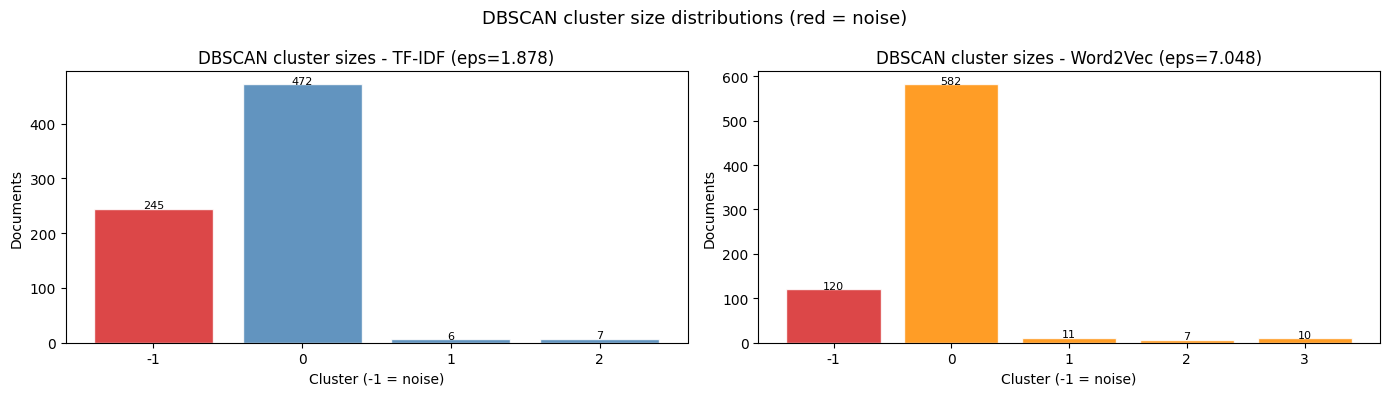

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, labels, title, color in [
    (axes[0], labels_dbscan_tfidf, f"TF-IDF (eps={EPS_TFIDF:.3f})",  "steelblue"),
    (axes[1], labels_dbscan_w2v,   f"Word2Vec (eps={EPS_W2V:.3f})",   "darkorange"),
]:
    counts = pd.Series(labels).value_counts().sort_index()
    bar_colors = ["#d62728" if i == -1 else color for i in counts.index]
    ax.bar([str(i) for i in counts.index], counts.values,
           color=bar_colors, edgecolor="white", alpha=0.85)
    ax.set_title(f"DBSCAN cluster sizes - {title}")
    ax.set_xlabel("Cluster (-1 = noise)")
    ax.set_ylabel("Documents")
    for xi, v in enumerate(counts.values):
        ax.text(xi, v + 1, str(v), ha="center", fontsize=8)

plt.suptitle("DBSCAN cluster size distributions (red = noise)", fontsize=13)
plt.tight_layout()
plt.savefig("../report/figures/05_2_dbscan_sizes.png", dpi=150)
plt.show()

## 6. Externe Validierung: DBSCAN Cluster vs. Hauptgruppen

In [10]:
df['cluster_dbscan_tfidf'] = labels_dbscan_tfidf
df['cluster_dbscan_w2v']   = labels_dbscan_w2v

hg_order = [str(i) for i in range(1, 10) if str(i) in df['hauptgruppe'].unique()]
if 'S' in df['hauptgruppe'].unique():
    hg_order.append('S')

print("Legende: " + " | ".join(f"{k}={v}" for k, v in HAUPTGRUPPEN.items()))

print("\n=== DBSCAN TF-IDF: Cluster x Hauptgruppe (-1 = noise) ===")
ct_dt = pd.crosstab(df['cluster_dbscan_tfidf'], df['hauptgruppe'])
ct_dt = ct_dt[[c for c in hg_order if c in ct_dt.columns]]
print(ct_dt.to_string())

print("\n=== DBSCAN Word2Vec: Cluster x Hauptgruppe (-1 = noise) ===")
ct_dw = pd.crosstab(df['cluster_dbscan_w2v'], df['hauptgruppe'])
ct_dw = ct_dw[[c for c in hg_order if c in ct_dw.columns]]
print(ct_dw.to_string())

Legende: 1=Staatsrecht/Org. | 2=Zivilrecht/Strafrecht | 3=Gesundheit | 4=Erziehung/Wiss. | 5=Polizei/Militaer | 6=Finanzen/Lieg. | 7=Bau/Energie/Umwelt | 8=Arbeit/Soziales | 9=Wirtschaft/Verkehr

=== DBSCAN TF-IDF: Cluster x Hauptgruppe (-1 = noise) ===
hauptgruppe             1   2   3   4   5   6   7   8   9  S
cluster_dbscan_tfidf                                        
-1                     43  25  14  48  12  12  43  31  16  1
 0                    110  42  43  63  41  19  59  39  53  3
 1                      0   0   0   6   0   0   0   0   0  0
 2                      0   0   0   0   0   0   0   7   0  0

=== DBSCAN Word2Vec: Cluster x Hauptgruppe (-1 = noise) ===
hauptgruppe           1   2   3   4   5   6   7   8   9  S
cluster_dbscan_w2v                                        
-1                   36  11   9  18   5   4  15  14   6  2
 0                  117  56  38  99  48  21  75  63  63  2
 1                    0   0   0   0   0   0  11   0   0  0
 2                    0 

## 7. Vergleich K-Means k=9 vs. DBSCAN

In [11]:
# Agreement: fraction of non-noise docs where K-Means and DBSCAN assign the same cluster
# (cluster IDs are not comparable, so we measure purity: for each DBSCAN cluster,
# what fraction belongs to the dominant K-Means cluster?)

def cluster_purity(labels_a, labels_b):
    """Mean purity of labels_a clusters w.r.t. labels_b."""
    mask = labels_a != -1
    a, b = labels_a[mask], labels_b[mask]
    purities = []
    for cid in set(a):
        b_in_cluster = b[a == cid]
        dominant = pd.Series(b_in_cluster).value_counts().iloc[0]
        purities.append(dominant / len(b_in_cluster))
    return np.mean(purities)

km9_tfidf = km_results['cluster_tfidf_9'].values
km9_w2v   = km_results['cluster_w2v_9'].values

pur_t = cluster_purity(labels_dbscan_tfidf, km9_tfidf)
pur_w = cluster_purity(labels_dbscan_w2v,   km9_w2v)

print("Cluster purity: mean fraction of DBSCAN cluster dominated by one K-Means cluster")
print(f"  TF-IDF:   {pur_t:.3f}")
print(f"  Word2Vec: {pur_w:.3f}")
print()
print("Interpretation: 1.0 = DBSCAN cluster perfectly contained in one K-Means cluster.")
print("Values > 0.7 suggest broad agreement on major groupings.")

# Summary table
print("\n=== Comparison Summary ===")
rows = []
for name, lbl_db, lbl_km, X in [
    ("TF-IDF",   labels_dbscan_tfidf, km9_tfidf, X_tfidf),
    ("Word2Vec", labels_dbscan_w2v,   km9_w2v,   X_w2v),
]:
    n_db   = len(set(lbl_db)) - (1 if -1 in lbl_db else 0)
    noise  = (lbl_db == -1).sum()
    sil_db = silhouette_score(X, lbl_db) if n_db >= 2 else float('nan')
    sil_km = silhouette_score(X, lbl_km)
    rows.append([name, 9, sil_km, n_db, noise, f"{noise/len(lbl_db)*100:.0f}%", sil_db])

cmp = pd.DataFrame(rows, columns=[
    "Repr.", "K-Means k", "K-Means Sil.",
    "DBSCAN clusters", "DBSCAN noise", "Noise %", "DBSCAN Sil."
])
print(cmp.to_string(index=False))

Cluster purity: mean fraction of DBSCAN cluster dominated by one K-Means cluster
  TF-IDF:   0.959
  Word2Vec: 0.772

Interpretation: 1.0 = DBSCAN cluster perfectly contained in one K-Means cluster.
Values > 0.7 suggest broad agreement on major groupings.

=== Comparison Summary ===
   Repr.  K-Means k  K-Means Sil.  DBSCAN clusters  DBSCAN noise Noise %  DBSCAN Sil.
  TF-IDF          9      0.184758                3           245     34%     0.207191
Word2Vec          9      0.112338                4           120     16%    -0.014075


## 8. Persist

In [ ]:
np.save(LABELS_DBSCAN_TFIDF_PATH, labels_dbscan_tfidf)
np.save(LABELS_DBSCAN_W2V_PATH,   labels_dbscan_w2v)
print(f"Saved DBSCAN labels -> {LABELS_DBSCAN_TFIDF_PATH}")
print(f"Saved DBSCAN labels -> {LABELS_DBSCAN_W2V_PATH}")

# Append DBSCAN labels to results CSV
km_results['cluster_dbscan_tfidf'] = labels_dbscan_tfidf
km_results['cluster_dbscan_w2v']   = labels_dbscan_w2v
km_results.to_csv(KMEANS_RESULTS, index=False)
print(f"Updated results CSV -> {KMEANS_RESULTS}")

## 9. Summary

**What we did:**
- Tuned eps via k-distance plot (k = min_samples - 1 = 4)
- Swept eps values and selected the eps with best silhouette among solutions with < 30% noise
- Ran final DBSCAN for both TF-IDF and Word2Vec PCA-50D
- Compared DBSCAN clusters to official SGBS Hauptgruppen
- Measured purity of DBSCAN clusters w.r.t. K-Means k=9 as a cross-method consistency check
- Saved DBSCAN labels and updated results CSV

**Next step:** `04_2_visualization.ipynb` - colour-coded t-SNE plots using K-Means and DBSCAN labels, and by Hauptgruppe.